# Bilevel Planning in KinDER

Bilevel planning solves complex manipulation tasks in two layers:

1. **Abstract task planning** — a symbolic planner searches over STRIPS operators to
   find a sequence of high-level actions (e.g. *pick*, *place*) that achieves the goal.
2. **Continuous skill execution** — each abstract action is paired with a parameterized
   controller that generates low-level motor commands to carry it out.

This notebook walks through setting up an environment, inspecting the
planning models, running the planner, and visualizing the result.

In [1]:
import tempfile
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
from PIL import Image as PILImage

import kinder
from bilevel_planning.abstract_plan_generators.heuristic_search_plan_generator import (
    RelationalHeuristicSearchAbstractPlanGenerator,
)
from bilevel_planning.bilevel_planners.sesame_planner import SesamePlanner
from bilevel_planning.structs import PlanningProblem
from bilevel_planning.trajectory_samplers.parameterized_controller_sampler import (
    ParameterizedControllerTrajectorySampler,
)
from bilevel_planning.utils import (
    RelationalAbstractSuccessorGenerator,
    RelationalControllerGenerator,
)
from kinder_bilevel_planning.agent import BilevelPlanningAgent
from kinder_bilevel_planning.env_models import create_bilevel_planning_models

## Setting Up the Environment

We use **Obstruction2D** with one obstruction — the robot must relocate the
obstacle before it can place the target block on the goal surface.

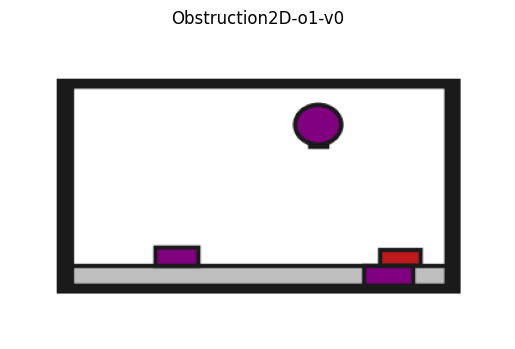

In [2]:
kinder.register_all_environments()

env = kinder.make("kinder/Obstruction2D-o1-v0", render_mode="rgb_array")
obs, info = env.reset(seed=123)

frame = env.render()
plt.imshow(frame)
plt.axis("off")
plt.title("Obstruction2D-o1-v0")
plt.show()

## Creating the Bilevel Planning Models

The bilevel planning models define the abstract reasoning layer: object types,
symbolic predicates, STRIPS operators, and parameterized skills.

In [3]:
env_models = create_bilevel_planning_models(
    "obstruction2d",
    env.observation_space,
    env.action_space,
    num_obstructions=1,
)

## Predicates

Predicates are symbolic propositions that describe the current state
(e.g. *the robot is holding a block*, *a block is on the target surface*).

In [4]:
for predicate in sorted(env_models.predicates, key=str):
    print(predicate)

(HandEmpty ?x0 - crv_robot)
(Holding ?x0 - crv_robot ?x1 - rectangle)
(OnTable ?x0 - rectangle)
(OnTarget ?x0 - rectangle)


## Operators

Operators are lifted STRIPS actions. Each one declares typed parameters,
preconditions, and effects — defining how a skill changes the abstract state.

In [5]:
for operator in sorted(env_models.operators, key=lambda o: o.name):
    print(operator)
    print()

(:action PickFromTable
    :parameters (?robot - crv_robot ?block - rectangle)
    :precondition (and (HandEmpty ?robot)
        (OnTable ?block))
    :effect (and (Holding ?robot ?block)
        (not (HandEmpty ?robot))
        (not (OnTable ?block)))
)

(:action PickFromTarget
    :parameters (?robot - crv_robot ?block - rectangle)
    :precondition (and (HandEmpty ?robot)
        (OnTarget ?block))
    :effect (and (Holding ?robot ?block)
        (not (HandEmpty ?robot))
        (not (OnTarget ?block)))
)

(:action PlaceOnTable
    :parameters (?robot - crv_robot ?block - rectangle)
    :precondition (and (Holding ?robot ?block))
    :effect (and (HandEmpty ?robot)
        (OnTable ?block)
        (not (Holding ?robot ?block)))
)

(:action PlaceOnTarget
    :parameters (?robot - crv_robot ?block - rectangle)
    :precondition (and (Holding ?robot ?block))
    :effect (and (HandEmpty ?robot)
        (OnTarget ?block)
        (not (Holding ?robot ?block)))
)



## Skills

Each skill pairs an operator with a parameterized controller that generates
the low-level actions to execute it.

In [6]:
for skill in sorted(env_models.skills, key=lambda s: s.operator.name):
    print(f"{skill.operator.name:20s} -> {type(skill.controller).__name__}")

PickFromTable        -> LiftedParameterizedController
PickFromTarget       -> LiftedParameterizedController
PlaceOnTable         -> LiftedParameterizedController
PlaceOnTarget        -> LiftedParameterizedController


## Running the Planner

Below we build the planner step by step — the same components that `BilevelPlanningAgent` assembles internally.

In [7]:
seed = 123
obs, info = env.reset(seed=seed)

initial_state = env_models.observation_to_state(obs)
goal = env_models.goal_deriver(initial_state)

problem = PlanningProblem(
    env_models.state_space,
    env_models.action_space,
    initial_state,
    env_models.transition_fn,
    goal,
)

trajectory_sampler = ParameterizedControllerTrajectorySampler(
    controller_generator=RelationalControllerGenerator(env_models.skills),
    transition_function=env_models.transition_fn,
    state_abstractor=env_models.state_abstractor,
    max_trajectory_steps=100,
)

abstract_plan_generator = RelationalHeuristicSearchAbstractPlanGenerator(
    env_models.types,
    env_models.predicates,
    env_models.operators,
    "hff",
    seed=seed,
)

abstract_successor_fn = RelationalAbstractSuccessorGenerator(env_models.operators)

planner = SesamePlanner(
    abstract_plan_generator,
    trajectory_sampler,
    max_abstract_plans=10,
    num_sampling_attempts_per_step=1,
    abstract_successor_function=abstract_successor_fn,
    state_abstractor=env_models.state_abstractor,
    seed=seed,
)

plan, bpg = planner.run(problem, timeout=30.0)
print(f"Plan found with {len(plan.actions)} actions")

Plan found with 130 actions


## Visualizing the Bilevel Planning Graph

The planner returns a **bilevel planning graph** (BPG) that records every
abstract state, concrete state, and action explored during search. We can
render it as an animated GIF to see how the planner expanded the search tree.

In [ ]:
with tempfile.TemporaryDirectory() as tmpdir:
    gif_path = Path(tmpdir) / "bpg.gif"
    bpg.render_gif(gif_path, title="Bilevel Planning Graph")
    display(Image(filename=str(gif_path), format="gif"))

## Executing the Plan

We step through the plan actions directly in the environment and collect
rendered frames.

In [ ]:
obs, info = env.reset(seed=seed)
frames = [env.render()]
total_reward = 0.0

for action in plan.actions:
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    frames.append(env.render())
    if terminated or truncated:
        break

print(f"Done in {len(frames)} steps, total reward: {total_reward:.2f}")

pil_frames = [PILImage.fromarray(f) for f in frames]
buf = BytesIO()
pil_frames[0].save(
    buf,
    format="GIF",
    save_all=True,
    append_images=pil_frames[1:],
    duration=100,
    loop=0,
)
Image(data=buf.getvalue(), format="gif")

## Using BilevelPlanningAgent

`BilevelPlanningAgent` wraps the planner setup above into a convenient
agent interface — call `reset()` to plan, then `step()` to get actions
one at a time.

In [ ]:
agent = BilevelPlanningAgent(
    env_models,
    seed=seed,
    max_abstract_plans=10,
    samples_per_step=1,
)

obs, info = env.reset(seed=seed)
agent.reset(obs, info)

frames = [env.render()]
total_reward = 0.0

for _ in range(1000):
    action = agent.step()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    agent.update(obs, reward, terminated or truncated, info)
    frames.append(env.render())
    if terminated or truncated:
        break

print(f"Done in {len(frames)} steps, total reward: {total_reward:.2f}")

pil_frames = [PILImage.fromarray(f) for f in frames]
buf = BytesIO()
pil_frames[0].save(
    buf,
    format="GIF",
    save_all=True,
    append_images=pil_frames[1:],
    duration=100,
    loop=0,
)
Image(data=buf.getvalue(), format="gif")

## Cleanup

In [ ]:
env.close()